In [8]:
from src.preferential_attachment_graph import PreferentialAttachmentGraph, FitnessType
from src.drawer import Drawer
from scipy.optimize import root_scalar
import numpy as np

In [24]:
N_VALUES = [50, 100, 500, 1000]
M = 1
REPS = 1000
FITNESS = FitnessType.LOG
FITNESS_ALPHA = 1

### Test Expected Weight Sums over Time

In [25]:
def calculate_theta(fitness: FitnessType, fitness_alpha: float) -> float:
    if fitness == FitnessType.LINEAR:
        f = lambda i: i + 1
    elif fitness == FitnessType.POLY:
        f = lambda i: (i + 1) ** fitness_alpha
    elif fitness == FitnessType.LOG:
        f = lambda i: np.log(i + 2)  ** fitness_alpha
    else:
        raise ValueError("Unsupported fitness type")
    
    def target_function(theta, max_i=2000, tolerance=1e-12):
        total_sum = 0.0
        current_product = 1.0
        
        for i in range(max_i):
            term = f(i) / (theta + f(i))
            current_product *= term
            total_sum += current_product
            
            if current_product < tolerance:
                break
                
        return total_sum - 1.0

    try:
        result = root_scalar(target_function, bracket=[0.1, 10], method='bisect')
        return result.root if result.converged else None
    except ValueError as e:
        print("Error: Make sure the solution is within the specified interval (bracket).")
        return None

In [26]:
def expected_weight_sum(t: float, theta: float) -> float:
    return theta * t

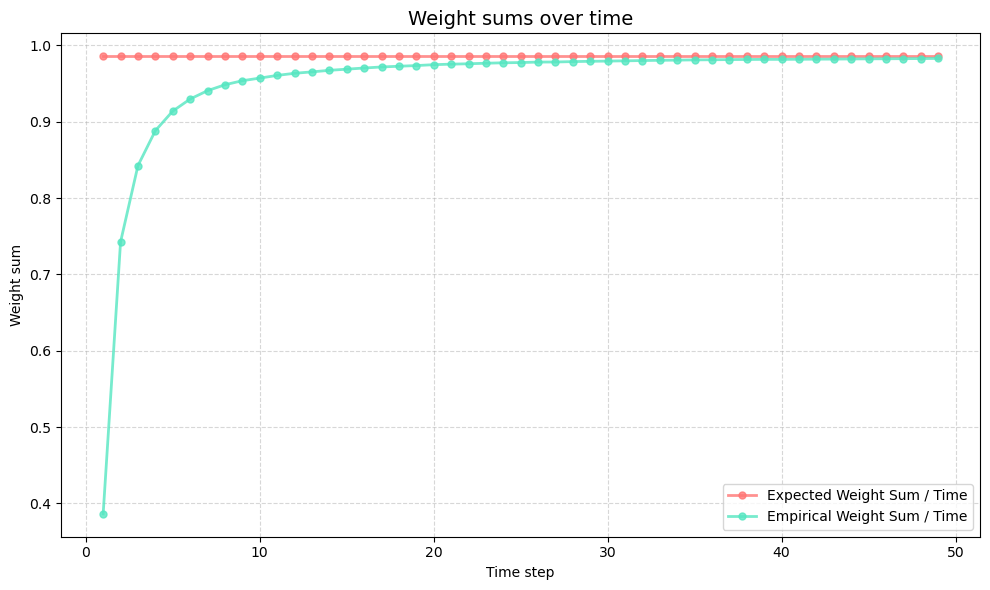

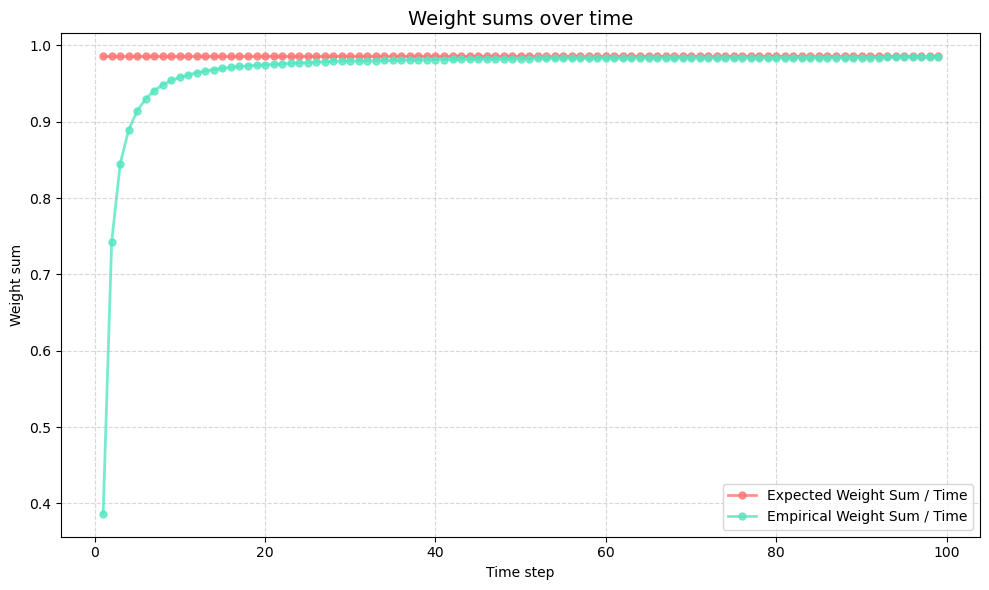

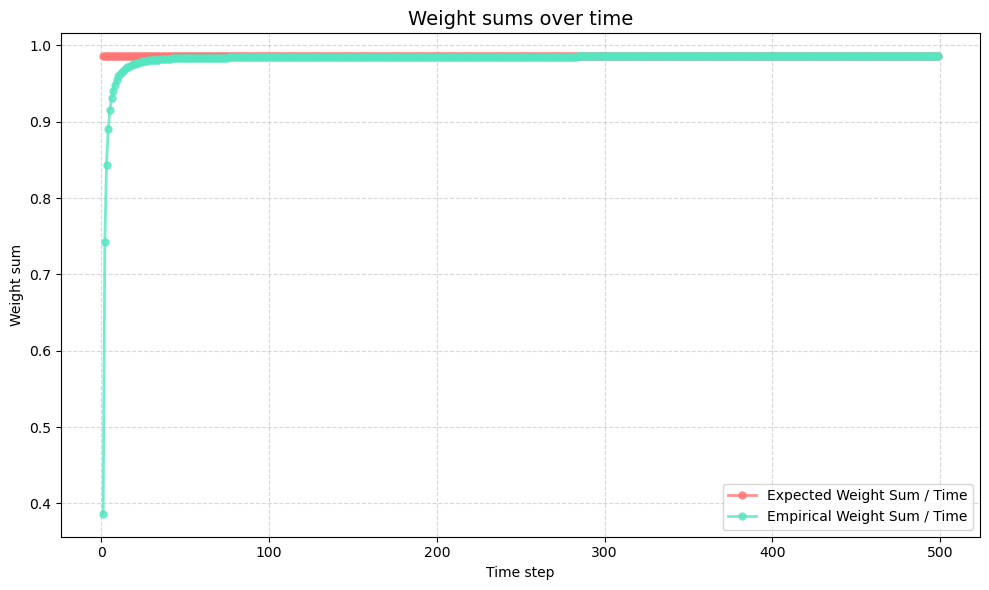

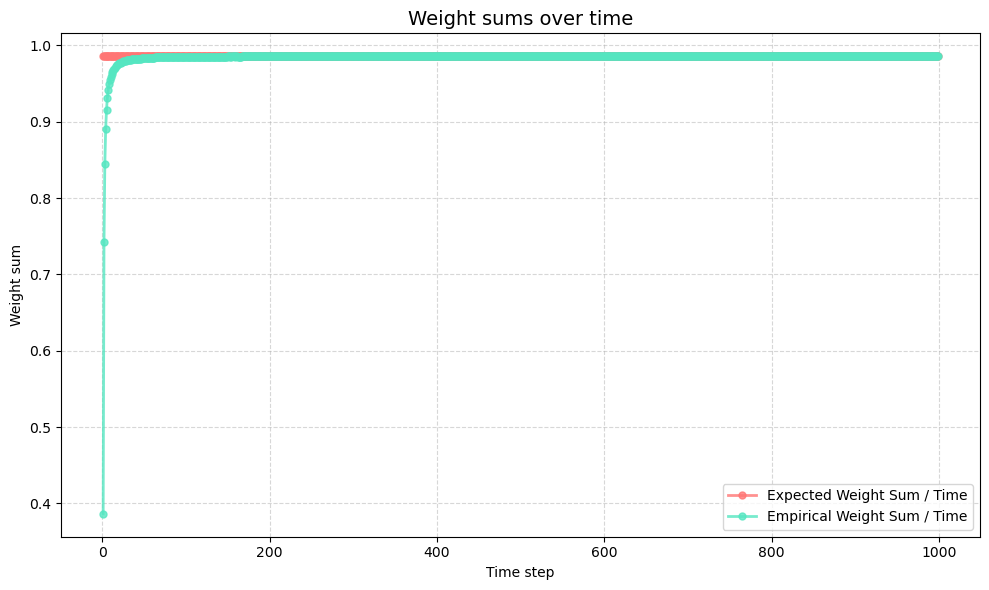

In [27]:
for N in N_VALUES:
    weight_sums = PreferentialAttachmentGraph.run_test_weight_sums(REPS, N, M, FITNESS, FITNESS_ALPHA)
    weight_sums = weight_sums.get("averaged_weights", [])

    theta = calculate_theta(FITNESS, FITNESS_ALPHA)

    steps = range(1, N * M)
    expected_weight_sums = [expected_weight_sum(t, theta) for t in steps]

    weight_sums_div_t = [(ws - 1) / t for ws, t in zip(weight_sums, steps)]
    expected_weight_sums_div_t = [ews / t for ews, t in zip(expected_weight_sums, steps)]

    drawer = Drawer()
    drawer.draw_line_chart(
        steps,
        [
            {
                "label": "Expected Weight Sum / Time", 
                "values": expected_weight_sums_div_t,
                "color": "color2"
            },
            {
                "label": "Empirical Weight Sum / Time", 
                "values": weight_sums_div_t,
                "color": "color3"
            },
        ],
        title="Weight sums over time",
        xlabel="Time step",
        ylabel="Weight sum"
    )

### Test Expected Degrees over Time

In [ ]:
def expected_degree(v, t, fitness_type: FitnessType, fitness_alpha: float) -> float:
    if t < v:
        return 0
    
    C = 0.7
    return (1 + C * np.log(t / v + 1)) ** (1 / (1 - fitness_alpha))

In [29]:
for N in N_VALUES:
    degrees = PreferentialAttachmentGraph.run_test_degrees(REPS, N, M, FitnessType.LOG, 1)
    degrees = degrees.get("averaged_degrees", [])

    steps = range(1, N * M)
    expected_degrees = {v: [expected_degree(v, t, FITNESS, FITNESS_ALPHA) for t in steps] for v in [5, 30, 45]}

    drawer.draw_line_chart(
        steps,
        [
            {
                "label": f"Expected Degrees of node {v}",
                "values": expected_degrees[v],
                "color": "color2"
            } for v in [5, 30, 45]
        ] + [
            {
                "label": f"Empirical Degrees of node {v}", 
                "values": degrees[v],
                "color": "color3"
            } for v in [5, 30, 45]
        ],
        title="Degrees over time",
        xlabel="Node index",
        ylabel="Degree"
    )

ZeroDivisionError: division by zero